In [1]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
%matplotlib inline

In [2]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

In [3]:
generation_list = []

for i in range(10002):
    generation_list.append(i)
    
print(len(generation_list))

10002


In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20180426_Collect new data for paper figures_Global U =0.1_S =-10%\Data\180828 New Data\Figure 5A. Amito vs Sex_Dele Only_N =20")

In [5]:
file_20 = ['Fitness_WF_Amito_20_P45_L1_180827_10KG.csv','Fitness_WF_Mito_20_P45_L1_180827_10KG.csv', 'Fitness_WF_RM_20_MUL_NewSex_180827.csv','Fitness_WF_RM_E100_20_MUL_NewSex_180827.csv',
'Fitness_WF_SF_20_MUL_NewSex_180827.csv', 'Fitness_WF_SF_E100_20_MUL_NewSex_180827.csv']

In [6]:
f20_fit_mean = []
f20_fit_std = []

for i in file_20:
    f = pd.read_csv(i,dtype=str)
    
    fit_mean = []
    fit_std = []
       
    fit_mean.extend(list(pd.Series(f.meanFit,dtype=float)))
    fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
        
    f20_fit_mean.append(fit_mean)
    f20_fit_std.append(fit_std)

Figure 4A. Fitness comparison of Amito vs Sex_Deleterious only_N =20

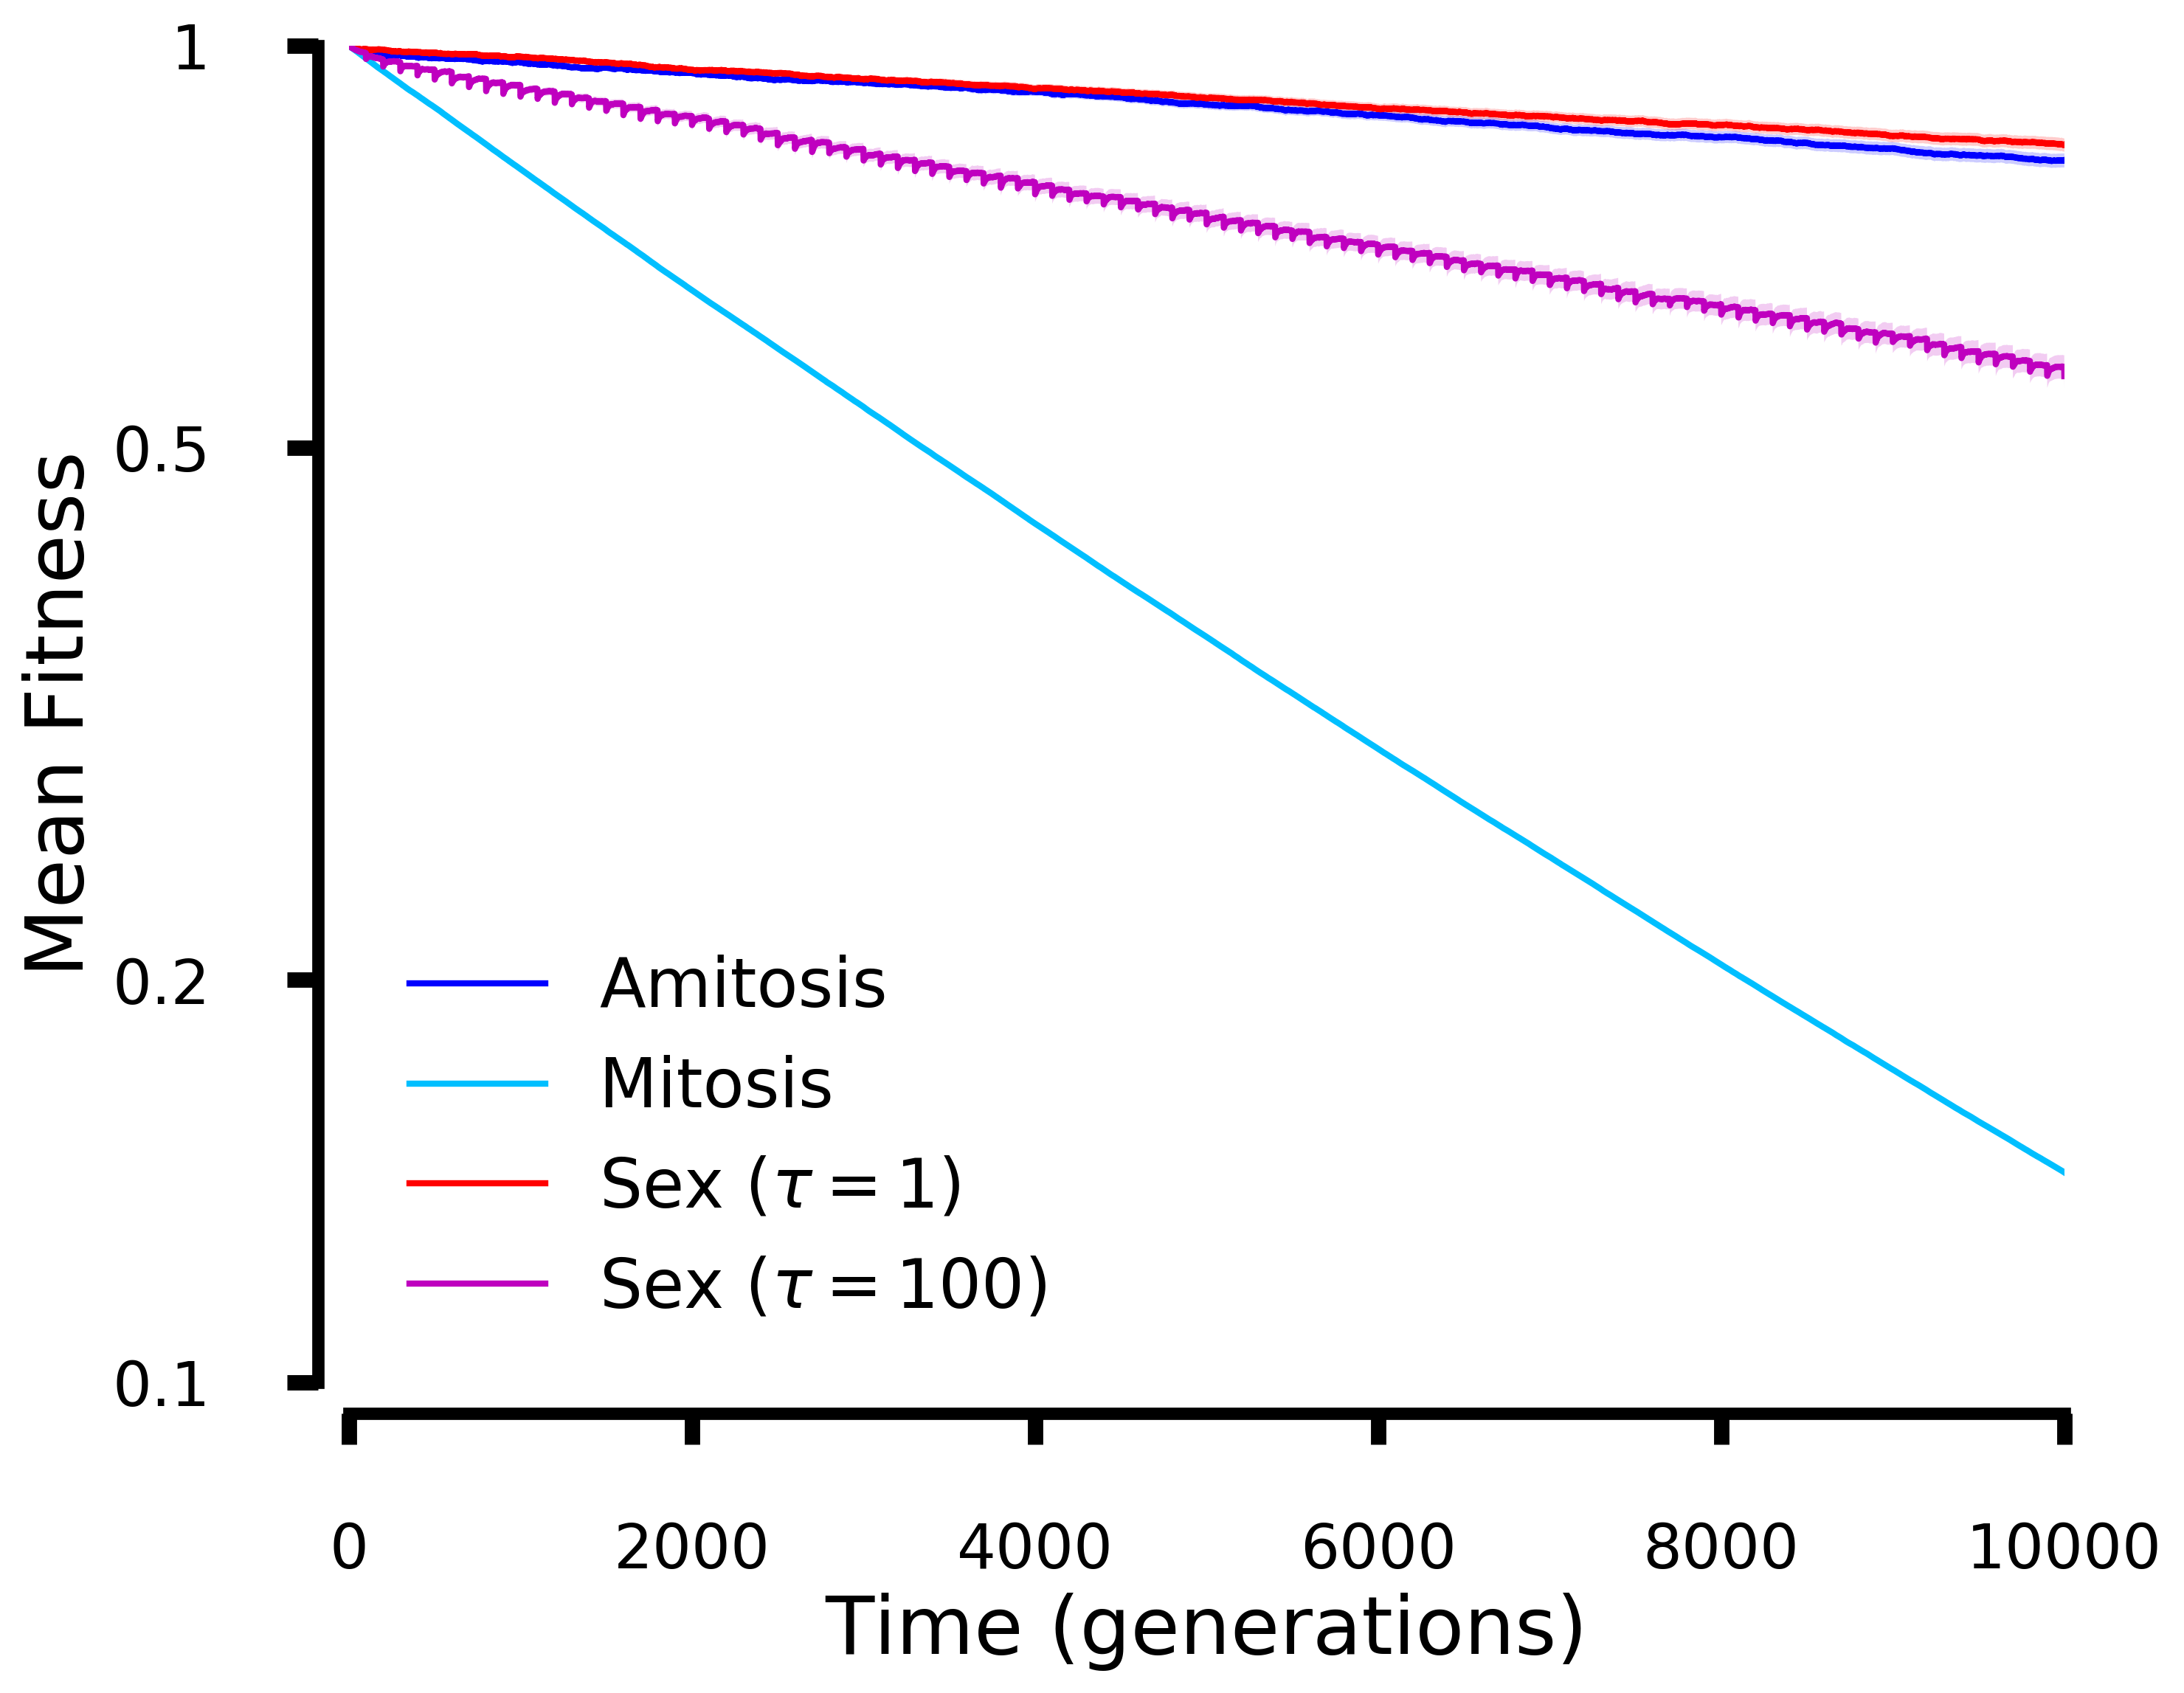

In [10]:
# For 2019 EE Symposium_Revised
fig = plt.figure(figsize=(10, 8), dpi = 300)
ax = fig.add_subplot(111)
publication_figure(ax)

ax.set_xlim(0,10000)
ax.set_ylim(10**(-1), 1)

t = generation_list

a = f20_fit_mean[0]  # Amito
error_a = list(1.96* np.array(f20_fit_std[0])/((500)**0.5))

b = f20_fit_mean[1]  # Mito
error_b = list(1.96* np.array(f20_fit_std[1])/((500)**0.5))


c = f20_fit_mean[2] # RM_Every G
error_c = list(1.96* np.array(f20_fit_std[2])/((500)**0.5))


d = f20_fit_mean[3] # RM_Every 100G
error_d = list(1.96* np.array(f20_fit_std[3])/((500)**0.5))


# ax.set_title('Amitosis vs. mitosis', fontsize =23)
ax.set_xlabel('Time (generations)', fontsize =26)
ax.set_ylabel('Mean Fitness', fontsize =26)

ax.set_yscale('log')

ax.plot(t,a,'b', label = 'Amitosis',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a)- np.array(error_a), np.array(a)+ np.array(error_a), alpha =0.2, facecolor='b')

ax.plot(t,b,'deepskyblue', label = 'Mitosis', linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(b)- np.array(error_b), np.array(b)+ np.array(error_b), alpha =0.2, facecolor='deepskyblue')

ax.plot(t,c,'r', label = r"Sex $(\tau=1)$", linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(c)- np.array(error_c), np.array(c)+ np.array(error_c), alpha =0.2, facecolor='r')

ax.plot(t,d,'m', label = r"Sex $(\tau=100)$", linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(d)- np.array(error_d), np.array(d)+ np.array(error_d), alpha =0.2, facecolor='m')

ax.set_yticks([0.1, 0.2, 0.5, 1]) # choose which x locations to have ticks
ax.set_yticklabels([0.1, 0.2, 0.5, 1]) # set the labels to display at those ticks


ax.minorticks_off()

plt.legend(loc='lower left', frameon=False, prop={'size':22})

# plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))